# Exponentially-weighted moving variance

In [54]:
import jax
import chex
import pandas as pd
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

In [37]:
%config InlineBackend.figure_format = "retina"

In [138]:
key = jax.random.PRNGKey(314)

In [139]:
from pandas_datareader import data

In [140]:
start_date = "2020-01-1"
end_date = "2020-12-31"
prices = data.DataReader('^SPX', 'stooq')

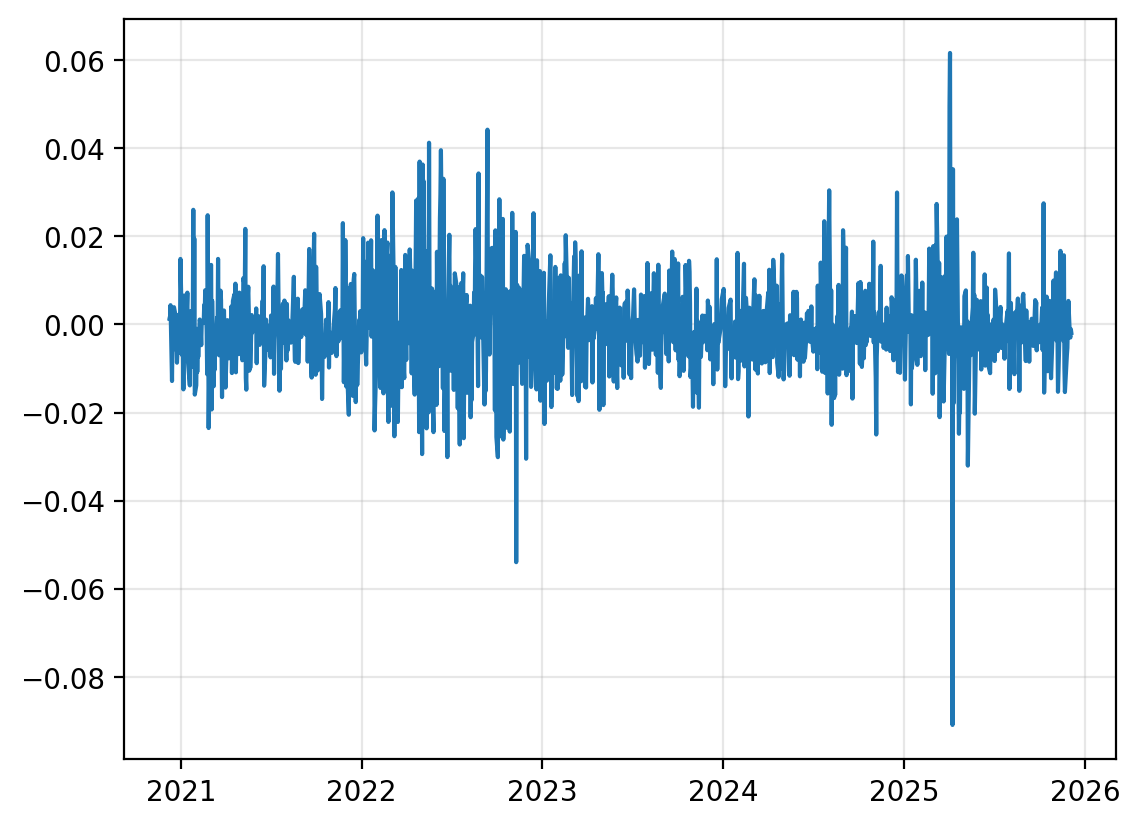

In [141]:
log_returns = np.log1p(prices["Close"].pct_change())
plt.plot(log_returns)
plt.grid(alpha=0.3)

## Exponentially weighted moving average and variance

In [142]:
@chex.dataclass
class Bel:
    mean: float
    var: float

def step(bel, x, alpha):
    diff = x - bel.mean
    incr = alpha * diff
    mean = bel.mean + incr
    variance = (1 - alpha) * (bel.var + diff * incr)
    bel = bel.replace(
        mean=mean,
        var=variance
    )
    return bel, bel

In [143]:
_step = partial(step, alpha=0.1)
bel_init = Bel(mean=0.0, var=1e-5)
bel_final, bel_hist = jax.lax.scan(_step, bel_init, log_returns.dropna().values)
bel_final

Bel(mean=Array(-0.00108167, dtype=float32), var=Array(3.9639643e-05, dtype=float32))

Text(0.5, 0.98, '^SPX')

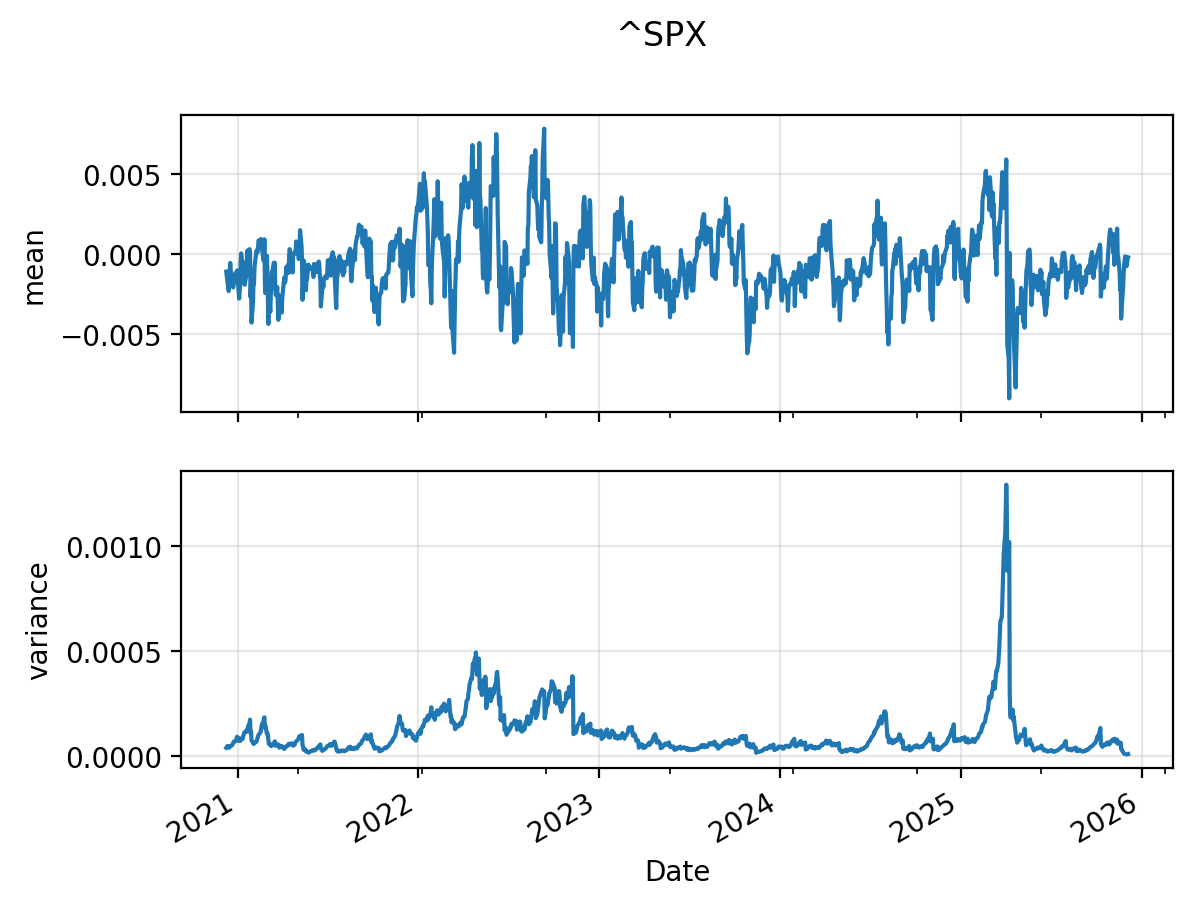

In [144]:
df_res = pd.DataFrame({
    "mean": bel_hist.mean,
    "var": bel_hist.var
}, log_returns.index[1:])

fig, ax = plt.subplots(2, 1, sharex=True)
df_res["mean"].plot(ax=ax[0])
df_res["var"].plot(ax=ax[1])

ax[0].set_ylabel("mean")
ax[1].set_ylabel("variance")
for axi in ax:
    axi.grid(alpha=0.3)

plt.suptitle("^SPX")

## Sources:

* https://fanf2.user.srcf.net/hermes/doc/antiforgery/stats.pdf